# Notebook 07 (rank-64) - MVP 3 Three-Branch Naive Concat over rank-64 MVP 2

Single-variable extension of MVP 3 (NB 07) over the rank-64 MVP 2 backbone produced by `06_mvp2_rank64`. MVP 3 itself trains only Branch C + heads (the MVP 2 backbone is frozen) so there is no LoRA-rank change inside this notebook - the rank-64 effect flows in through the loaded frozen encoders.

**Changes vs MVP 3 baseline:**
- `epochs`: 5 -> **10**
- `text_adapter`: `models/roberta_mvp1_d` -> `models/rank64/roberta_run_d_r64`
- `mvp2_best_dir`: `models/mvp2_naive_concat_best` -> `models/rank64/mvp2_naive_concat_r64_best`

Branch C, standardisation protocol, loss formulation, optimiser identical to MVP 3. Output paths point to `models/rank64/mvp3_three_branch_r64[_best]/` and `outputs/nb07_r64_*.png`.


In [1]:
import os, sys, json, random, gc, time, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix,
                              classification_report)
from sklearn.utils.class_weight import compute_class_weight
from transformers import (AutoTokenizer, AutoModel,
                          CLIPVisionModel, CLIPModel, CLIPImageProcessor,
                          get_cosine_schedule_with_warmup)
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
if torch.cuda.is_available():
    print(f'gpu mem: {torch.cuda.get_device_properties(0).total_memory/1024**3:.2f} GB')

HPARAMS = dict(
    max_len=128,
    image_size=224,
    batch_size=16,
    epochs=10,
    clip_lora_rank=16,
    clip_lora_alpha=32,
    struct_lr=1e-3,
    head_lr=1e-3,
    warmup_ratio=0.1,
    gamma=2.0,
    grad_accum_steps=4,
    threshold=0.5,
    t1_weight=0.7,
    t2_weight=0.3,
    weight_decay=0.01,
    dropout=0.1,
    struct_hidden=32,
    n_struct_features=9,
    ocr_len_clip_percentile=0.99,
    text_base='cardiffnlp/twitter-roberta-base-2022-154m',
    text_adapter='models/rank64/roberta_run_d_r64',
    clip_model='openai/clip-vit-base-patch16',
    mvp2_best_dir='models/rank64/mvp2_naive_concat_r64_best',
    prior_hate=0.2468,
    prior_nothate=0.7532,
    n_t2_classes=6,
    seed=SEED,
)
for k, v in HPARAMS.items():
    print(f'  {k}: {v}')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
LABELS_CSV = ROOT / 'data' / 'processed' / 'labels_parsed.csv'
STRUCT_CSV = ROOT / 'data' / 'processed' / 'structured_features.csv'
SPLITS_DIR = ROOT / 'data' / 'MMHS150K' / 'splits'
IMG_DIR    = ROOT / 'data' / 'MMHS150K' / 'img_resized'
TEXT_ADAPTER_DIR = ROOT / HPARAMS['text_adapter']
MVP2_BEST_DIR    = ROOT / HPARAMS['mvp2_best_dir']
OUT_DIR   = ROOT / 'outputs'
MODEL_DIR = ROOT / 'models' / 'rank64' / 'mvp3_three_branch_r64'
BEST_DIR  = ROOT / 'models' / 'rank64' / 'mvp3_three_branch_r64_best'
for d in [OUT_DIR, MODEL_DIR, BEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
for p, name in [(LABELS_CSV, 'LABELS_CSV'), (STRUCT_CSV, 'STRUCT_CSV'),
                 (SPLITS_DIR, 'SPLITS_DIR'), (IMG_DIR, 'IMG_DIR'),
                 (TEXT_ADAPTER_DIR, 'TEXT_ADAPTER_DIR'),
                 (MVP2_BEST_DIR, 'MVP2_BEST_DIR')]:
    print(f'  {name:<18} exists={p.exists()}  -> {p}')

device: cuda | NVIDIA L4
gpu mem: 22.03 GB
  max_len: 128
  image_size: 224
  batch_size: 16
  epochs: 10
  clip_lora_rank: 16
  clip_lora_alpha: 32
  struct_lr: 0.001
  head_lr: 0.001
  warmup_ratio: 0.1
  gamma: 2.0
  grad_accum_steps: 4
  threshold: 0.5
  t1_weight: 0.7
  t2_weight: 0.3
  weight_decay: 0.01
  dropout: 0.1
  struct_hidden: 32
  n_struct_features: 9
  ocr_len_clip_percentile: 0.99
  text_base: cardiffnlp/twitter-roberta-base-2022-154m
  text_adapter: models/rank64/roberta_run_d_r64
  clip_model: openai/clip-vit-base-patch16
  mvp2_best_dir: models/rank64/mvp2_naive_concat_r64_best
  prior_hate: 0.2468
  prior_nothate: 0.7532
  n_t2_classes: 6
  seed: 42
ROOT: /teamspace/studios/this_studio/HateFusion
  LABELS_CSV         exists=True  -> /teamspace/studios/this_studio/HateFusion/data/processed/labels_parsed.csv
  STRUCT_CSV         exists=True  -> /teamspace/studios/this_studio/HateFusion/data/processed/structured_features.csv
  SPLITS_DIR         exists=True  -> /team

In [2]:
# Load labels + structured features, merge on tweet_id, attach official splits.
df_lab = pd.read_csv(LABELS_CSV)
df_str = pd.read_csv(STRUCT_CSV)
print('labels raw shape :', df_lab.shape, '| nulls:', df_lab.isna().sum().to_dict())
print('struct raw shape :', df_str.shape, '| nulls:', df_str.isna().sum().to_dict())

# Canonical feature order (positional, deterministic regardless of CSV column order).
FEATURE_ORDER = [
    'vader_neg', 'vader_neu', 'n_emoji', 'hate_keyword_count',
    'ocr_present', 'profanity_count', 'n_hashtags', 'ocr_len', 'n_mentions',
]
BINARY_FEATURES = ['ocr_present']
NON_BINARY_FEATURES = [c for c in FEATURE_ORDER if c not in BINARY_FEATURES]
assert len(FEATURE_ORDER) == 9 and len(NON_BINARY_FEATURES) == 8
assert set(FEATURE_ORDER).issubset(df_str.columns), \
    f'missing struct cols: {set(FEATURE_ORDER) - set(df_str.columns)}'

df = df_lab.merge(df_str[['tweet_id'] + FEATURE_ORDER], on='tweet_id', how='inner')
print('post-merge shape :', df.shape, '| nulls:', df.isna().sum().to_dict())

def read_ids(p):
    return set(int(line.strip()) for line in open(p) if line.strip())

splits = {
    'train': read_ids(SPLITS_DIR / 'train_ids.txt'),
    'val':   read_ids(SPLITS_DIR / 'val_ids.txt'),
    'test':  read_ids(SPLITS_DIR / 'test_ids.txt'),
}
print(f'split txt sizes: train={len(splits["train"])} val={len(splits["val"])} test={len(splits["test"])}')

def assign_split(tid):
    for name, s in splits.items():
        if tid in s:
            return name
    return 'unassigned'

df['split'] = df['tweet_id'].map(assign_split)
df = df[df['split'].isin(['train', 'val', 'test'])].reset_index(drop=True)
print('\npost-split shape :', df.shape, '| nulls:', df.isna().sum().to_dict())

# Verify no nulls in structured feature columns.
struct_nulls = df[FEATURE_ORDER].isna().sum()
print('\nstruct feature nulls:')
print(struct_nulls.to_string())
assert struct_nulls.sum() == 0, 'NaN in structured features after merge — inspect upstream'

T2_NAMES = ['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']
print('\nper-split T1 + T2 distribution:')
print(f'  {"split":<6} {"n":>7} {"%T1=hate":>9} {"t2_valid":>10} {"t2_NaN":>8}')
for s in ['train', 'val', 'test']:
    sub = df[df['split'] == s]
    n_t2_valid = int(sub['t2_valid'].sum())
    n_t2_nan = int(sub['T2'].isna().sum())
    print(f'  {s:<6} {len(sub):>7} {sub["T1"].mean()*100:>8.2f}% {n_t2_valid:>10} {n_t2_nan:>8}')
    if n_t2_valid > 0:
        t2_dist = sub.loc[sub['t2_valid'], 'T2'].astype(int).value_counts().sort_index()
        named = {T2_NAMES[i]: int(c) for i, c in t2_dist.items()}
        print(f'         T2 dist (valid only): {named}')

labels raw shape : (149819, 10) | nulls: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0}
struct raw shape : (149819, 10) | nulls: {'tweet_id': 0, 'vader_neg': 0, 'vader_neu': 0, 'n_emoji': 0, 'ocr_present': 0, 'n_hashtags': 0, 'ocr_len': 0, 'hate_keyword_count': 0, 'profanity_count': 0, 'n_mentions': 0}
post-merge shape : (149819, 19) | nulls: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0, 'vader_neg': 0, 'vader_neu': 0, 'n_emoji': 0, 'hate_keyword_count': 0, 'ocr_present': 0, 'profanity_count': 0, 'n_hashtags': 0, 'ocr_len': 0, 'n_mentions': 0}
split txt sizes: train=134823 val=5000 test=10000



post-split shape : (149819, 20) | nulls: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0, 'vader_neg': 0, 'vader_neu': 0, 'n_emoji': 0, 'hate_keyword_count': 0, 'ocr_present': 0, 'profanity_count': 0, 'n_hashtags': 0, 'ocr_len': 0, 'n_mentions': 0, 'split': 0}

struct feature nulls:
vader_neg             0
vader_neu             0
n_emoji               0
hate_keyword_count    0
ocr_present           0
profanity_count       0
n_hashtags            0
ocr_len               0
n_mentions            0

per-split T1 + T2 distribution:
  split        n  %T1=hate   t2_valid   t2_NaN
  train   134820    21.86%     125501     9319
         T2 dist (valid only): {'NotHate': 105344, 'Racist': 9505, 'Sexist': 2790, 'Homophobe': 3087, 'Religion': 130, 'OtherHate': 4645}
  val       4999    50.01%       4197      802
         T2 dist (valid only): {'NotHate': 2499, 'Racist': 809, 'Sexist': 241, 'Homophobe

In [3]:
# Standardisation statistics from TRAIN SPLIT ONLY.
# 1. Clip `ocr_len` at train 99th-percentile BEFORE computing mean/std.
# 2. Z-score the 8 non-binary features using train mean/std.
# 3. Binary features (`ocr_present`) stay in {0,1} — no transform.
# Stats are saved with the checkpoint so MVP 4 can apply the same transform.
train_mask = (df['split'] == 'train')
train_struct = df.loc[train_mask, FEATURE_ORDER].copy()
print('train_struct shape:', train_struct.shape)

ocr_len_clip = float(train_struct['ocr_len'].quantile(HPARAMS['ocr_len_clip_percentile']))
print(f'\nocr_len train P{int(HPARAMS["ocr_len_clip_percentile"]*100)} clip value: {ocr_len_clip:.2f}')
print(f'  train ocr_len pre-clip range: [{train_struct["ocr_len"].min():.0f}, {train_struct["ocr_len"].max():.0f}]'
      f' mean={train_struct["ocr_len"].mean():.2f}')
train_struct['ocr_len'] = train_struct['ocr_len'].clip(upper=ocr_len_clip)
print(f'  train ocr_len post-clip range: [{train_struct["ocr_len"].min():.0f}, {train_struct["ocr_len"].max():.0f}]'
      f' mean={train_struct["ocr_len"].mean():.2f}')

feature_means = {}
feature_stds  = {}
for col in NON_BINARY_FEATURES:
    mu = float(train_struct[col].mean())
    sd = float(train_struct[col].std(ddof=0))
    if sd < 1e-12:
        print(f'  WARN  zero std for {col} on train; falling back to std=1.0')
        sd = 1.0
    feature_means[col] = mu
    feature_stds[col]  = sd

STRUCT_STATS = {
    'feature_order': FEATURE_ORDER,
    'binary_features': BINARY_FEATURES,
    'non_binary_features': NON_BINARY_FEATURES,
    'ocr_len_clip': ocr_len_clip,
    'ocr_len_clip_percentile': HPARAMS['ocr_len_clip_percentile'],
    'feature_means': feature_means,
    'feature_stds': feature_stds,
}

print('\nstandardisation stats (TRAIN ONLY):')
print(f'  {"feature":<20} {"train_mean":>12} {"train_std":>12} {"transform":>14}')
for col in FEATURE_ORDER:
    if col in NON_BINARY_FEATURES:
        if col == 'ocr_len':
            transform = f'clip@{ocr_len_clip:.0f} + z'
        else:
            transform = 'z-score'
        print(f'  {col:<20} {feature_means[col]:>12.4f} {feature_stds[col]:>12.4f} {transform:>14}')
    else:
        print(f'  {col:<20} {"—":>12} {"—":>12} {"identity[0,1]":>14}')

train_struct shape: (134820, 9)

ocr_len train P99 clip value: 389.00
  train ocr_len pre-clip range: [0, 3128] mean=31.19
  train ocr_len post-clip range: [0, 389] mean=29.38

standardisation stats (TRAIN ONLY):
  feature                train_mean    train_std      transform
  vader_neg                  0.1725       0.1866        z-score
  vader_neu                  0.7298       0.2067        z-score
  n_emoji                    0.5630       1.5614        z-score
  hate_keyword_count         0.7224       0.4846        z-score
  ocr_present                     —            —  identity[0,1]
  profanity_count            0.9150       0.8332        z-score
  n_hashtags                 0.2024       0.7893        z-score
  ocr_len                   29.3807      68.8518   clip@389 + z
  n_mentions                 0.5289       0.8290        z-score


In [4]:
# Image audit — drop rows whose image is not on disk. Per EDA Q1 all 149,819 GT-referenced
# images are present; this is defensive belt-and-braces against any stray missing file.
print(f'enumerating .jpg files in {IMG_DIR} ...')
_t = time.time()
available_ids = set()
for p in IMG_DIR.iterdir():
    if p.suffix.lower() == '.jpg':
        try:
            available_ids.add(int(p.stem))
        except ValueError:
            continue
print(f'  scandir done in {time.time()-_t:.1f}s, {len(available_ids):,} .jpg files indexed')

before = len(df)
df['img_exists'] = df['tweet_id'].isin(available_ids)
missing_per_split = df[~df['img_exists']].groupby('split').size().to_dict()
print(f'\nrows with no image on disk (per split): {missing_per_split}')
df = df[df['img_exists']].reset_index(drop=True).drop(columns=['img_exists'])
after = len(df)
print(f'dropped {before - after} rows due to missing images. shape: {df.shape}')

print('\nfinal per-split sizes:')
for s in ['train', 'val', 'test']:
    sub = df[df['split'] == s]
    print(f'  {s:<6} n={len(sub):>7} T1 hate%={sub["T1"].mean()*100:5.2f}% t2_valid={int(sub["t2_valid"].sum())}')
print('nulls after drop:', df.isna().sum().to_dict())

enumerating .jpg files in /teamspace/studios/this_studio/HateFusion/data/MMHS150K/img_resized ...


  scandir done in 0.5s, 150,000 .jpg files indexed

rows with no image on disk (per split): {}
dropped 0 rows due to missing images. shape: (149819, 20)

final per-split sizes:
  train  n= 134820 T1 hate%=21.86% t2_valid=125501
  val    n=   4999 T1 hate%=50.01% t2_valid=4197
  test   n=  10000 T1 hate%=50.01% t2_valid=8411
nulls after drop: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0, 'vader_neg': 0, 'vader_neu': 0, 'n_emoji': 0, 'hate_keyword_count': 0, 'ocr_present': 0, 'profanity_count': 0, 'n_hashtags': 0, 'ocr_len': 0, 'n_mentions': 0, 'split': 0}


In [5]:
# Tokeniser, image processor, dataset class with structured features.
tokenizer = AutoTokenizer.from_pretrained(HPARAMS['text_base'])
image_processor = CLIPImageProcessor.from_pretrained(HPARAMS['clip_model'])
print('tokenizer:', tokenizer.__class__.__name__, '| vocab:', tokenizer.vocab_size)
print('image_processor:', image_processor.__class__.__name__, '| size:', image_processor.size)
print('image_processor mean/std:', image_processor.image_mean, '/', image_processor.image_std)

def apply_struct_transform(df_sub, stats):
    """Returns (N, 9) float32 array in FEATURE_ORDER, with train stats applied.
    Clip ocr_len at train P99, z-score the 8 non-binary features, leave ocr_present untouched."""
    out = np.zeros((len(df_sub), len(stats['feature_order'])), dtype=np.float32)
    for j, col in enumerate(stats['feature_order']):
        v = df_sub[col].to_numpy(dtype=np.float32)
        if col == 'ocr_len':
            v = np.minimum(v, stats['ocr_len_clip'])
        if col in stats['non_binary_features']:
            mu = stats['feature_means'][col]
            sd = stats['feature_stds'][col]
            v = (v - mu) / sd
        out[:, j] = v
    return out

class MMHS150KThreeBranchDataset(Dataset):
    """Pre-tokenizes text once. Pre-computes standardised structured features once.
    Loads images lazily per __getitem__. Hashtags/mentions/URLs preserved verbatim.
    T2 NaN rows are stored with placeholder 0 and masked via t2_valid_mask."""
    def __init__(self, sub_df, tok, img_proc, img_dir, max_len, struct_stats):
        texts = sub_df['tweet_text'].astype(str).tolist()
        enc = tok(texts, truncation=True, padding='max_length',
                  max_length=max_len, return_tensors='pt')
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.t1_labels = torch.tensor(sub_df['T1'].to_numpy(dtype=np.float32))
        t2_arr = sub_df['T2'].fillna(0).to_numpy(dtype=np.int64)
        self.t2_labels = torch.tensor(t2_arr, dtype=torch.long)
        self.t2_valid_mask = torch.tensor(
            sub_df['t2_valid'].to_numpy(dtype=np.bool_), dtype=torch.bool)
        self.tweet_ids = sub_df['tweet_id'].to_numpy(dtype=np.int64)
        self.struct_features = torch.tensor(
            apply_struct_transform(sub_df, struct_stats), dtype=torch.float32)
        self.img_dir = Path(img_dir)
        self.img_proc = img_proc
    def __len__(self):
        return self.t1_labels.size(0)
    def __getitem__(self, idx):
        tid = int(self.tweet_ids[idx])
        with Image.open(self.img_dir / f'{tid}.jpg') as im:
            if im.mode != 'RGB':
                im = im.convert('RGB')
            pixel = self.img_proc(im, return_tensors='pt')['pixel_values'].squeeze(0)
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'pixel_values': pixel,
            'structured': self.struct_features[idx],
            't1_label': self.t1_labels[idx],
            't2_label': self.t2_labels[idx],
            't2_valid_mask': self.t2_valid_mask[idx],
            'tweet_id': tid,
        }

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)
print(f'\nsplit frames: train {train_df.shape} | val {val_df.shape} | test {test_df.shape}')

print('tokenising text + computing structured features (one pass per split)...')
_t = time.time()
train_ds = MMHS150KThreeBranchDataset(train_df, tokenizer, image_processor, IMG_DIR, HPARAMS['max_len'], STRUCT_STATS)
val_ds   = MMHS150KThreeBranchDataset(val_df,   tokenizer, image_processor, IMG_DIR, HPARAMS['max_len'], STRUCT_STATS)
test_ds  = MMHS150KThreeBranchDataset(test_df,  tokenizer, image_processor, IMG_DIR, HPARAMS['max_len'], STRUCT_STATS)
print(f'  done in {time.time()-_t:.1f}s')
print(f'datasets: train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=HPARAMS['batch_size'], shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=HPARAMS['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=HPARAMS['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)

_b = train_ds[0]
print(f'sample shapes: input_ids {tuple(_b["input_ids"].shape)}, '
      f'pixel_values {tuple(_b["pixel_values"].shape)}, structured {tuple(_b["structured"].shape)}, '
      f't1 {_b["t1_label"].item()}, t2 {_b["t2_label"].item()}, t2_valid {bool(_b["t2_valid_mask"].item())}')
print(f'structured (post-transform) sample: {_b["structured"].numpy().round(4).tolist()}')

tokenizer: RobertaTokenizer | vocab: 50265
image_processor: CLIPImageProcessor | size: SizeDict(height=None, width=None, longest_edge=None, shortest_edge=224, max_height=None, max_width=None)
image_processor mean/std: (0.48145466, 0.4578275, 0.40821073) / (0.26862954, 0.26130258, 0.27577711)

split frames: train (134820, 20) | val (4999, 20) | test (10000, 20)
tokenising text + computing structured features (one pass per split)...


  done in 21.6s
datasets: train 134820 | val 4999 | test 10000
sample shapes: input_ids (128,), pixel_values (3, 224, 224), structured (9,), t1 1.0, t2 0, t2_valid False
structured (post-transform) sample: [-0.9243999719619751, 1.3072999715805054, -0.36059999465942383, -1.4905999898910522, 1.0, -1.0981999635696411, -0.2563999891281128, -0.16529999673366547, 0.5683000087738037]


In [6]:
# Loss functions (same shape as MVP 2).
y_train_t1 = train_df['T1'].to_numpy()
cw_t1 = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train_t1)
pos_weight_value = float(cw_t1[1] / cw_t1[0])
pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
print(f'T1 class weights from TRAIN: nothate={cw_t1[0]:.4f}, hate={cw_t1[1]:.4f}')
print(f'T1 pos_weight (hate/nothate ratio): {pos_weight_value:.4f}')

class FocalBCE(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight
    def forward(self, logits, target):
        logits = logits.view(-1)
        target = target.view(-1).float()
        bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none')
        p = torch.sigmoid(logits)
        pt = p * target + (1.0 - p) * (1.0 - target)
        focal = (1.0 - pt).pow(self.gamma) * bce
        if self.pos_weight is not None:
            w = target * self.pos_weight + (1.0 - target)
            focal = focal * w
        return focal.mean()

criterion_t1 = FocalBCE(gamma=HPARAMS['gamma'], pos_weight=pos_weight)
print(f'criterion_t1: FocalBCE(gamma={HPARAMS["gamma"]}, pos_weight={pos_weight_value:.4f})')

y_train_t2_valid = train_df.loc[train_df['t2_valid'], 'T2'].astype(int).to_numpy()
cw_t2_np = compute_class_weight('balanced',
                                 classes=np.arange(HPARAMS['n_t2_classes']),
                                 y=y_train_t2_valid)
cw_t2 = torch.tensor(cw_t2_np, dtype=torch.float32, device=device)
print(f'\nT2 class weights from TRAIN (t2_valid=True only):')
for i, w in enumerate(cw_t2_np):
    n_i = int((y_train_t2_valid == i).sum())
    print(f'  {T2_NAMES[i]:>10s}  weight={w:.4f}  train_count={n_i}')

class MaskedFocalCE(nn.Module):
    def __init__(self, gamma=2.0, weight=None, num_classes=6):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.num_classes = num_classes
    def forward(self, logits, target, mask):
        logp = F.log_softmax(logits, dim=-1)
        p = logp.exp()
        idx = target.unsqueeze(1).clamp_(min=0, max=self.num_classes - 1)
        t_logp = logp.gather(1, idx).squeeze(1)
        t_p = p.gather(1, idx).squeeze(1)
        focal = (1.0 - t_p).pow(self.gamma) * (-t_logp)
        if self.weight is not None:
            w = self.weight.gather(0, target.clamp(min=0, max=self.num_classes - 1))
            focal = focal * w
        m = mask.float()
        n_valid = m.sum()
        if n_valid.item() == 0:
            return logits.sum() * 0.0
        return (focal * m).sum() / n_valid

criterion_t2 = MaskedFocalCE(gamma=HPARAMS['gamma'], weight=cw_t2,
                              num_classes=HPARAMS['n_t2_classes'])
print(f'\ncriterion_t2: MaskedFocalCE(gamma={HPARAMS["gamma"]}, weight=<train-balanced>)')
print(f'combined loss = {HPARAMS["t1_weight"]} * t1_loss + {HPARAMS["t2_weight"]} * t2_loss_masked_mean')

T1 class weights from TRAIN: nothate=0.6399, hate=2.2869
T1 pos_weight (hate/nothate ratio): 3.5739
criterion_t1: FocalBCE(gamma=2.0, pos_weight=3.5739)

T2 class weights from TRAIN (t2_valid=True only):
     NotHate  weight=0.1986  train_count=105344
      Racist  weight=2.2006  train_count=9505
      Sexist  weight=7.4971  train_count=2790
   Homophobe  weight=6.7758  train_count=3087
    Religion  weight=160.8987  train_count=130
   OtherHate  weight=4.5031  train_count=4645

criterion_t2: MaskedFocalCE(gamma=2.0, weight=<train-balanced>)
combined loss = 0.7 * t1_loss + 0.3 * t2_loss_masked_mean


In [7]:
# Build the three-branch model. Strategy:
#   1. Construct submodules matching MVP 2's layout (text encoder + LoRA, vision encoder + LoRA,
#      frozen 768->512 visual projection, 512->768 image projection).
#   2. Load the MVP 2 vision LoRA adapter into the vision encoder, and the MVP 2 image_projection
#      weights into the projection module.
#   3. Freeze ALL of the above (text was already frozen; CLIP LoRA + image_projection are newly
#      frozen here per locked decision #1).
#   4. Add a fresh Branch C MLP (9 -> 32) and fresh T1/T2 heads on the 1568-d concat.

class MVP3ThreeBranch(nn.Module):
    """Frozen MVP 2 (text + vision + image_projection) + trainable structured-features branch + fresh heads."""
    def __init__(self,
                 text_base: str, text_adapter_dir: str,
                 clip_model_name: str, mvp2_best_dir: str,
                 n_struct: int = 9, struct_hidden: int = 32,
                 n_t2_classes: int = 6, dropout: float = 0.1):
        super().__init__()

        # --- TEXT BRANCH (frozen Run D LoRA) ---------------------------------
        base_text = AutoModel.from_pretrained(text_base)
        self.text_encoder = PeftModel.from_pretrained(
            base_text, text_adapter_dir, is_trainable=False)
        for p in self.text_encoder.parameters():
            p.requires_grad = False
        self.text_encoder.eval()

        # --- IMAGE BRANCH (CLIP vision + MVP 2 LoRA, frozen) -----------------
        # Lift the canonical 768->512 visual_projection from the public CLIPModel.
        clip_full = CLIPModel.from_pretrained(clip_model_name)
        vis_proj_weight = clip_full.visual_projection.weight.detach().clone()
        del clip_full
        gc.collect()

        vision_base = CLIPVisionModel.from_pretrained(clip_model_name)
        # Attach MVP 2's trained LoRA adapter (NOT a fresh one).
        self.vision_encoder = PeftModel.from_pretrained(
            vision_base, mvp2_best_dir, is_trainable=False)
        for p in self.vision_encoder.parameters():
            p.requires_grad = False
        self.vision_encoder.eval()

        clip_hidden = vision_base.config.hidden_size  # 768
        self.visual_projection_to_512 = nn.Linear(clip_hidden, 512, bias=False)
        self.visual_projection_to_512.weight.data = vis_proj_weight
        for p in self.visual_projection_to_512.parameters():
            p.requires_grad = False

        # 512->768 image projection: load MVP 2's trained weights, then freeze.
        self.image_projection = nn.Linear(512, 768)
        rest = torch.load(Path(mvp2_best_dir) / 'rest.pt', map_location='cpu', weights_only=False)
        self.image_projection.load_state_dict(rest['image_projection'])
        for p in self.image_projection.parameters():
            p.requires_grad = False
        self._mvp2_meta = {
            'epoch': int(rest.get('epoch', -1)),
            'val_t1_auc': float(rest.get('val_t1_auc', float('nan'))),
            'val_t2_macro_f1': float(rest.get('val_t2_macro_f1', float('nan'))),
        }
        del rest

        # --- STRUCTURED BRANCH (TRAINABLE, fresh) ----------------------------
        self.struct_branch = nn.Sequential(
            nn.Linear(n_struct, struct_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # --- FUSION HEADS (TRAINABLE, fresh; cannot reuse MVP 2 heads --- dim changed) ---
        fused_dim = 768 + 768 + struct_hidden  # 1568
        hidden = 256
        self.head_t1 = nn.Sequential(
            nn.Linear(fused_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
        self.head_t2 = nn.Sequential(
            nn.Linear(fused_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_t2_classes),
        )

    def encode_text(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0]   # (B, 768)

    def encode_image(self, pixel_values):
        # Same PEFT-0.19 / transformers-5.x workaround as MVP 2: bypass PeftModel.forward.
        with torch.no_grad():
            out = self.vision_encoder.base_model.model(pixel_values=pixel_values)
            pooled = out.pooler_output                       # (B, 768)
            feat_512 = self.visual_projection_to_512(pooled) # (B, 512)
            img_768  = self.image_projection(feat_512)       # (B, 768)
        return img_768

    def encode_struct(self, structured):
        return self.struct_branch(structured)                # (B, 32)

    def forward(self, input_ids, attention_mask, pixel_values, structured):
        txt = self.encode_text(input_ids, attention_mask)    # (B, 768)
        img = self.encode_image(pixel_values)                # (B, 768)
        stc = self.encode_struct(structured)                 # (B, 32)
        fused = torch.cat([img, txt, stc], dim=-1)           # (B, 1568)
        return self.head_t1(fused), self.head_t2(fused)


model = MVP3ThreeBranch(
    text_base=HPARAMS['text_base'],
    text_adapter_dir=str(TEXT_ADAPTER_DIR),
    clip_model_name=HPARAMS['clip_model'],
    mvp2_best_dir=str(MVP2_BEST_DIR),
    n_struct=HPARAMS['n_struct_features'],
    struct_hidden=HPARAMS['struct_hidden'],
    n_t2_classes=HPARAMS['n_t2_classes'],
    dropout=HPARAMS['dropout'],
).to(device)

print(f'\nMVP 2 backbone loaded from {MVP2_BEST_DIR} '
      f'(epoch {model._mvp2_meta["epoch"]}, val_t1_auc={model._mvp2_meta["val_t1_auc"]:.4f}).')

named = list(model.named_parameters())
total_params = sum(p.numel() for _, p in named)
trainable_total = sum(p.numel() for _, p in named if p.requires_grad)

def count(pred):
    return sum(p.numel() for n, p in named if pred(n, p))

text_trainable     = count(lambda n, p: n.startswith('text_encoder.') and p.requires_grad)
vision_trainable   = count(lambda n, p: n.startswith('vision_encoder.') and p.requires_grad)
vis_proj_trainable = count(lambda n, p: n.startswith('visual_projection_to_512.') and p.requires_grad)
img_proj_trainable = count(lambda n, p: n.startswith('image_projection.') and p.requires_grad)
struct_trainable   = count(lambda n, p: n.startswith('struct_branch.') and p.requires_grad)
head_t1_trainable  = count(lambda n, p: n.startswith('head_t1.') and p.requires_grad)
head_t2_trainable  = count(lambda n, p: n.startswith('head_t2.') and p.requires_grad)

print(f'\ntotal params:                          {total_params:>15,}')
print(f'trainable total:                       {trainable_total:>15,}  ({100*trainable_total/total_params:.4f}%)')
print(f'  text encoder trainable:              {text_trainable:>15,}  (must be 0)')
print(f'  CLIP vision (+ LoRA) trainable:      {vision_trainable:>15,}  (must be 0)')
print(f'  frozen visual_projection (768->512): {vis_proj_trainable:>15,}  (must be 0)')
print(f'  frozen image_projection (512->768):  {img_proj_trainable:>15,}  (must be 0)')
print(f'  struct_branch (TRAINABLE):           {struct_trainable:>15,}')
print(f'  head_t1       (TRAINABLE):           {head_t1_trainable:>15,}')
print(f'  head_t2       (TRAINABLE):           {head_t2_trainable:>15,}')

assert text_trainable == 0,     'TEXT ENCODER not frozen — violation of locked decision #1'
assert vision_trainable == 0,   'CLIP vision (including LoRA) not frozen — violation of locked decision #1'
assert vis_proj_trainable == 0, 'visual_projection_to_512 not frozen — bug'
assert img_proj_trainable == 0, 'image_projection not frozen — violation of locked decision #1'
assert struct_trainable > 0,    'struct_branch not trainable — nothing to learn'
assert head_t1_trainable > 0 and head_t2_trainable > 0, 'fresh heads not trainable — bug'
expected_trainable = struct_trainable + head_t1_trainable + head_t2_trainable
assert trainable_total == expected_trainable, \
    f'unexpected trainable params: {trainable_total} vs branch+heads {expected_trainable}'
print('\nFreeze surface verified: ONLY Branch C MLP + T1 head + T2 head receive gradients.')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1


MVP 2 backbone loaded from /teamspace/studios/this_studio/HateFusion/models/rank64/mvp2_naive_concat_r64_best (epoch 1, val_t1_auc=0.7501).

total params:                              216,756,295
trainable total:                               805,447  (0.3716%)
  text encoder trainable:                            0  (must be 0)
  CLIP vision (+ LoRA) trainable:                    0  (must be 0)
  frozen visual_projection (768->512):               0  (must be 0)
  frozen image_projection (512->768):                0  (must be 0)
  struct_branch (TRAINABLE):                       320
  head_t1       (TRAINABLE):                   401,921
  head_t2       (TRAINABLE):                   403,206

Freeze surface verified: ONLY Branch C MLP + T1 head + T2 head receive gradients.


In [8]:
# Optimiser + scheduler + AMP scaler.
struct_params = [p for n, p in model.named_parameters() if n.startswith('struct_branch.') and p.requires_grad]
head_params   = [p for n, p in model.named_parameters() if (n.startswith('head_t1.') or n.startswith('head_t2.')) and p.requires_grad]

covered = {id(p) for p in struct_params + head_params}
stragglers = [n for n, p in model.named_parameters() if p.requires_grad and id(p) not in covered]
assert not stragglers, f'trainable params not assigned to an optimiser group: {stragglers[:5]}'

optimizer = torch.optim.AdamW(
    [
        {'params': struct_params, 'lr': HPARAMS['struct_lr']},
        {'params': head_params,   'lr': HPARAMS['head_lr']},
    ],
    weight_decay=HPARAMS['weight_decay'],
)

data_steps_per_epoch = len(train_loader)
opt_steps_per_epoch  = data_steps_per_epoch // HPARAMS['grad_accum_steps']
total_opt_steps      = opt_steps_per_epoch * HPARAMS['epochs']
warmup_steps         = int(HPARAMS['warmup_ratio'] * total_opt_steps)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_opt_steps,
)

scaler = torch.amp.GradScaler('cuda')

print(f'data steps/epoch: {data_steps_per_epoch}')
print(f'opt  steps/epoch: {opt_steps_per_epoch}  (grad_accum={HPARAMS["grad_accum_steps"]}, effective batch={HPARAMS["batch_size"]*HPARAMS["grad_accum_steps"]})')
print(f'total opt steps:  {total_opt_steps}  |  warmup: {warmup_steps}')
print(f'param groups: struct lr={HPARAMS["struct_lr"]} ({len(struct_params)}) | heads lr={HPARAMS["head_lr"]} ({len(head_params)})')

data steps/epoch: 8427
opt  steps/epoch: 2106  (grad_accum=4, effective batch=64)
total opt steps:  21060  |  warmup: 2106
param groups: struct lr=0.001 (2) | heads lr=0.001 (8)


In [9]:
# Training loop: 5 epochs, fp16, grad-accum 4, save best by val_t1_auc.
history = {
    'epoch': [], 'train_total': [], 'train_t1': [], 'train_t2': [],
    'val_total': [], 'val_t1_loss': [], 'val_t2_loss': [],
    'val_t1_auc': [], 'val_t1_f1': [], 'val_t2_macro_f1': [],
}
best_t1_auc, best_epoch = -1.0, -1

for epoch in range(1, HPARAMS['epochs'] + 1):
    model.train()
    # Frozen encoders must stay in eval mode (no dropout, no batch-norm drift).
    model.text_encoder.eval()
    model.vision_encoder.eval()
    t0 = time.time()
    run_tot, run_t1, run_t2, n_batches = 0.0, 0.0, 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(train_loader):
        ids   = batch['input_ids'].to(device, non_blocking=True)
        mask  = batch['attention_mask'].to(device, non_blocking=True)
        pix   = batch['pixel_values'].to(device, non_blocking=True)
        stc   = batch['structured'].to(device, non_blocking=True)
        y1    = batch['t1_label'].to(device, non_blocking=True)
        y2    = batch['t2_label'].to(device, non_blocking=True)
        m2    = batch['t2_valid_mask'].to(device, non_blocking=True)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            logit_t1, logits_t2 = model(ids, mask, pix, stc)
            l_t1 = criterion_t1(logit_t1, y1)
            l_t2 = criterion_t2(logits_t2, y2, m2)
            loss = HPARAMS['t1_weight'] * l_t1 + HPARAMS['t2_weight'] * l_t2
            scaled_loss = loss / HPARAMS['grad_accum_steps']
        scaler.scale(scaled_loss).backward()
        run_tot += loss.item(); run_t1 += l_t1.item(); run_t2 += l_t2.item(); n_batches += 1
        if (step + 1) % HPARAMS['grad_accum_steps'] == 0:
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
    train_total = run_tot / max(n_batches, 1)
    train_t1    = run_t1  / max(n_batches, 1)
    train_t2    = run_t2  / max(n_batches, 1)

    # Validation
    model.eval()
    val_tot, val_t1l, val_t2l, nb = 0.0, 0.0, 0.0, 0
    v_t1_probs, v_t1_true, v_t2_preds, v_t2_true, v_t2_valid = [], [], [], [], []
    with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
        for batch in val_loader:
            ids  = batch['input_ids'].to(device, non_blocking=True)
            mask = batch['attention_mask'].to(device, non_blocking=True)
            pix  = batch['pixel_values'].to(device, non_blocking=True)
            stc  = batch['structured'].to(device, non_blocking=True)
            y1   = batch['t1_label'].to(device, non_blocking=True)
            y2   = batch['t2_label'].to(device, non_blocking=True)
            m2   = batch['t2_valid_mask'].to(device, non_blocking=True)
            logit_t1, logits_t2 = model(ids, mask, pix, stc)
            l_t1 = criterion_t1(logit_t1, y1)
            l_t2 = criterion_t2(logits_t2, y2, m2)
            val_tot += (HPARAMS['t1_weight'] * l_t1 + HPARAMS['t2_weight'] * l_t2).item()
            val_t1l += l_t1.item(); val_t2l += l_t2.item(); nb += 1
            v_t1_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
            v_t1_true.append(y1.cpu().numpy())
            v_t2_preds.append(logits_t2.argmax(dim=-1).cpu().numpy())
            v_t2_true.append(y2.cpu().numpy())
            v_t2_valid.append(m2.cpu().numpy())
    val_total   = val_tot  / max(nb, 1)
    val_t1_loss = val_t1l  / max(nb, 1)
    val_t2_loss = val_t2l  / max(nb, 1)
    v_t1_probs = np.concatenate(v_t1_probs); v_t1_true = np.concatenate(v_t1_true)
    v_t2_preds = np.concatenate(v_t2_preds); v_t2_true = np.concatenate(v_t2_true); v_t2_valid = np.concatenate(v_t2_valid)
    val_t1_auc = roc_auc_score(v_t1_true, v_t1_probs)
    val_t1_f1  = f1_score(v_t1_true, (v_t1_probs >= HPARAMS['threshold']).astype(int))
    if v_t2_valid.sum() > 0:
        val_t2_macro_f1 = f1_score(v_t2_true[v_t2_valid], v_t2_preds[v_t2_valid], average='macro',
                                    labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
    else:
        val_t2_macro_f1 = float('nan')

    elapsed = time.time() - t0
    print(f'[epoch {epoch}/{HPARAMS["epochs"]}] '
          f'train tot={train_total:.4f} t1={train_t1:.4f} t2={train_t2:.4f}  |  '
          f'val tot={val_total:.4f} t1={val_t1_loss:.4f} t2={val_t2_loss:.4f}  |  '
          f'val_t1_auc={val_t1_auc:.4f}  val_t1_f1={val_t1_f1:.4f}  val_t2_macro_f1={val_t2_macro_f1:.4f}  ({elapsed:.1f}s)')

    for k, v in [('epoch', epoch), ('train_total', train_total), ('train_t1', train_t1), ('train_t2', train_t2),
                 ('val_total', val_total), ('val_t1_loss', val_t1_loss), ('val_t2_loss', val_t2_loss),
                 ('val_t1_auc', val_t1_auc), ('val_t1_f1', val_t1_f1), ('val_t2_macro_f1', val_t2_macro_f1)]:
        history[k].append(v)

    if val_t1_auc > best_t1_auc:
        best_t1_auc = val_t1_auc; best_epoch = epoch
        torch.save({
            'struct_branch': model.struct_branch.state_dict(),
            'head_t1': model.head_t1.state_dict(),
            'head_t2': model.head_t2.state_dict(),
            'struct_stats': STRUCT_STATS,
            'epoch': epoch,
            'val_t1_auc': val_t1_auc,
            'val_t2_macro_f1': float(val_t2_macro_f1),
        }, BEST_DIR / 'mvp3_trainable.pt')
        with open(BEST_DIR / 'standardisation_stats.json', 'w') as f:
            json.dump(STRUCT_STATS, f, indent=2)
        print(f'  -> new best val_t1_auc={val_t1_auc:.4f}, saved to {BEST_DIR}')
    torch.cuda.empty_cache()

print(f'\nbest epoch: {best_epoch} | best val_t1_auc: {best_t1_auc:.4f}')

[epoch 1/10] train tot=0.3786 t1=0.2345 t2=0.7147  |  val tot=0.6327 t1=0.3490 t2=1.2947  |  val_t1_auc=0.7506  val_t1_f1=0.6675  val_t2_macro_f1=0.5307  (461.7s)
  -> new best val_t1_auc=0.7506, saved to /teamspace/studios/this_studio/HateFusion/models/rank64/mvp3_three_branch_r64_best


[epoch 2/10] train tot=0.3261 t1=0.2328 t2=0.5440  |  val tot=0.5819 t1=0.3246 t2=1.1821  |  val_t1_auc=0.7501  val_t1_f1=0.7023  val_t2_macro_f1=0.5269  (453.6s)


[epoch 3/10] train tot=0.3115 t1=0.2324 t2=0.4962  |  val tot=0.5788 t1=0.3480 t2=1.1171  |  val_t1_auc=0.7497  val_t1_f1=0.6827  val_t2_macro_f1=0.4834  (453.9s)


[epoch 4/10] train tot=0.3060 t1=0.2320 t2=0.4786  |  val tot=0.5573 t1=0.3445 t2=1.0538  |  val_t1_auc=0.7497  val_t1_f1=0.6958  val_t2_macro_f1=0.4868  (448.3s)


[epoch 5/10] train tot=0.2979 t1=0.2319 t2=0.4520  |  val tot=0.5831 t1=0.3521 t2=1.1221  |  val_t1_auc=0.7489  val_t1_f1=0.6848  val_t2_macro_f1=0.5225  (457.7s)


[epoch 6/10] train tot=0.2909 t1=0.2313 t2=0.4302  |  val tot=0.5751 t1=0.3545 t2=1.0897  |  val_t1_auc=0.7493  val_t1_f1=0.6889  val_t2_macro_f1=0.5095  (446.4s)


[epoch 7/10] train tot=0.2813 t1=0.2309 t2=0.3991  |  val tot=0.5660 t1=0.3521 t2=1.0651  |  val_t1_auc=0.7488  val_t1_f1=0.6763  val_t2_macro_f1=0.5147  (453.2s)


[epoch 8/10] train tot=0.2764 t1=0.2307 t2=0.3831  |  val tot=0.5571 t1=0.3438 t2=1.0549  |  val_t1_auc=0.7488  val_t1_f1=0.6877  val_t2_macro_f1=0.5051  (451.1s)


[epoch 9/10] train tot=0.2722 t1=0.2305 t2=0.3693  |  val tot=0.5652 t1=0.3470 t2=1.0741  |  val_t1_auc=0.7488  val_t1_f1=0.6831  val_t2_macro_f1=0.5146  (458.0s)


[epoch 10/10] train tot=0.2704 t1=0.2303 t2=0.3639  |  val tot=0.5659 t1=0.3493 t2=1.0712  |  val_t1_auc=0.7488  val_t1_f1=0.6820  val_t2_macro_f1=0.5143  (448.1s)

best epoch: 1 | best val_t1_auc: 0.7506


reloaded best (epoch 1, val_t1_auc=0.7506, val_t2_macro_f1=0.5307)



TEST T1 (balanced 50/50, threshold 0.5):
  AUC-ROC       : 0.7420
  F1 (macro)    : 0.6830
  Precision (M) : 0.6868
  Recall    (M) : 0.6841
  CM            : TN=3719 FP=1280 FN=1879 TP=3122
  FPR           : 0.2561

TEST T2 (t2_valid=True only, n=8411 / 10000):
  macro F1: 0.5496
              precision    recall  f1-score   support

     NotHate     0.7726    0.5357    0.6327      4999
      Racist     0.4279    0.5077    0.4644      1613
      Sexist     0.2693    0.7284    0.3933       464
   Homophobe     0.6100    0.9397    0.7398       531
    Religion     0.3636    0.5000    0.4211        24
   OtherHate     0.5957    0.7064    0.6463       780

    accuracy                         0.5822      8411
   macro avg     0.5065    0.6530    0.5496      8411
weighted avg     0.6509    0.5822    0.5947      8411



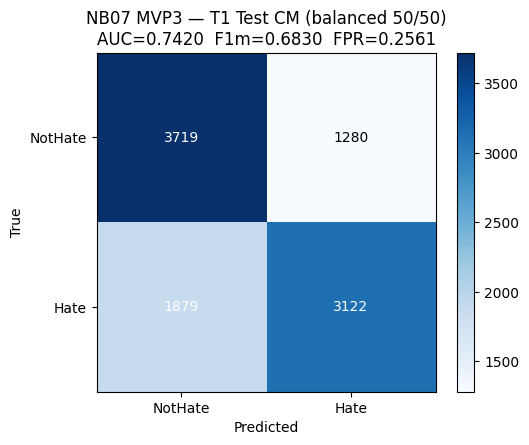

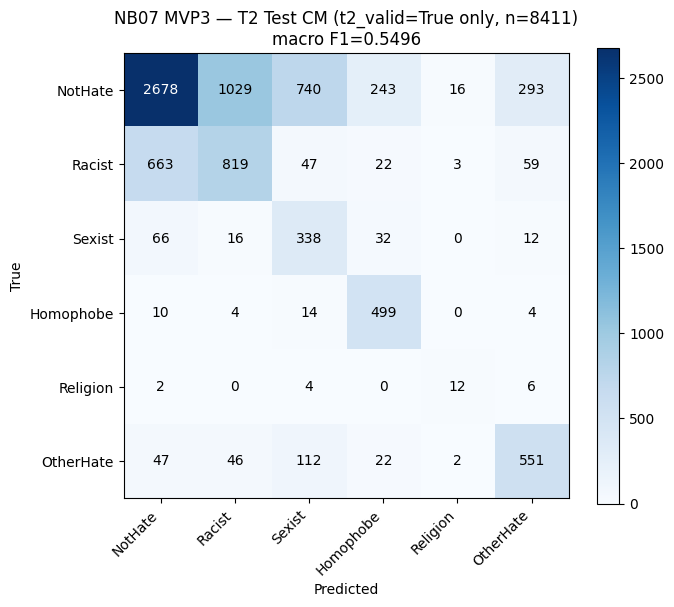

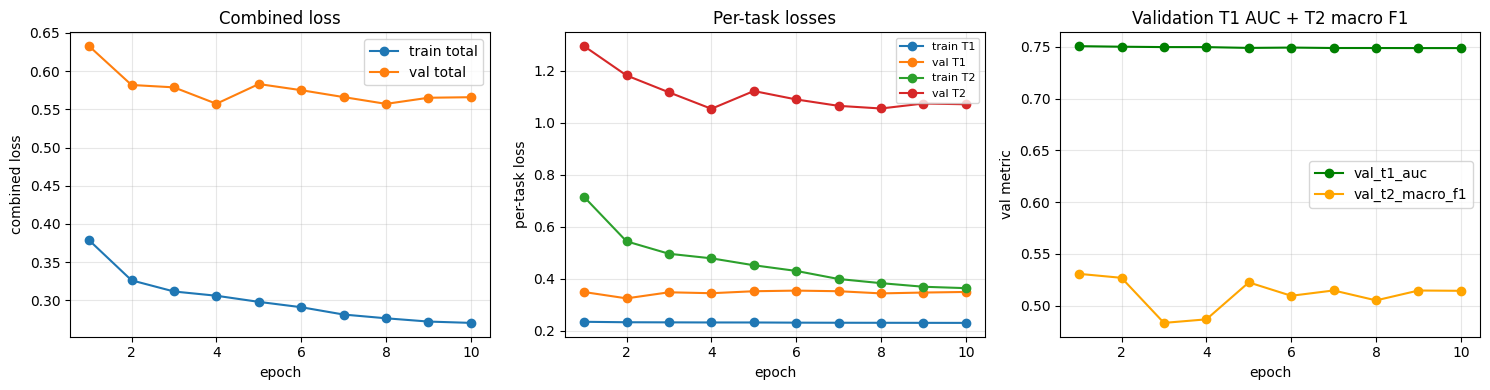

In [10]:
# Reload best checkpoint, run test-set evaluation, save charts.
rest = torch.load(BEST_DIR / 'mvp3_trainable.pt', map_location='cpu', weights_only=False)
model.struct_branch.load_state_dict(rest['struct_branch'])
model.head_t1.load_state_dict(rest['head_t1'])
model.head_t2.load_state_dict(rest['head_t2'])
model.to(device).eval()
print(f'reloaded best (epoch {rest["epoch"]}, val_t1_auc={rest["val_t1_auc"]:.4f}, '
      f'val_t2_macro_f1={rest["val_t2_macro_f1"]:.4f})')

t1_probs, t1_true, t2_preds, t2_true, t2_valid = [], [], [], [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in test_loader:
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        pix  = batch['pixel_values'].to(device, non_blocking=True)
        stc  = batch['structured'].to(device, non_blocking=True)
        logit_t1, logits_t2 = model(ids, mask, pix, stc)
        t1_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
        t1_true.append(batch['t1_label'].cpu().numpy())
        t2_preds.append(logits_t2.argmax(dim=-1).cpu().numpy())
        t2_true.append(batch['t2_label'].cpu().numpy())
        t2_valid.append(batch['t2_valid_mask'].cpu().numpy())
all_t1_probs = np.concatenate(t1_probs); all_t1_true = np.concatenate(t1_true)
all_t2_preds = np.concatenate(t2_preds); all_t2_true = np.concatenate(t2_true); all_t2_valid = np.concatenate(t2_valid)

# --- T1 metrics (balanced 50/50, threshold 0.5) -----------------------------
t1_pred = (all_t1_probs >= HPARAMS['threshold']).astype(int)
t1_auc  = roc_auc_score(all_t1_true, all_t1_probs)
t1_f1m  = f1_score(all_t1_true, t1_pred, average='macro')
t1_pm   = precision_score(all_t1_true, t1_pred, average='macro', zero_division=0)
t1_rm   = recall_score(all_t1_true, t1_pred, average='macro', zero_division=0)
cm_t1   = confusion_matrix(all_t1_true, t1_pred, labels=[0, 1])
tn, fp, fn, tp = cm_t1.ravel()
t1_fpr  = fp / max(fp + tn, 1)
print(f'\nTEST T1 (balanced 50/50, threshold {HPARAMS["threshold"]}):')
print(f'  AUC-ROC       : {t1_auc:.4f}')
print(f'  F1 (macro)    : {t1_f1m:.4f}')
print(f'  Precision (M) : {t1_pm:.4f}')
print(f'  Recall    (M) : {t1_rm:.4f}')
print(f'  CM            : TN={tn} FP={fp} FN={fn} TP={tp}')
print(f'  FPR           : {t1_fpr:.4f}')

# --- T2 metrics (t2_valid=True only) ----------------------------------------
mask_v = all_t2_valid.astype(bool)
n_valid_test = int(mask_v.sum())
print(f'\nTEST T2 (t2_valid=True only, n={n_valid_test} / {len(all_t2_valid)}):')
if n_valid_test > 0:
    t2_f1m_macro = f1_score(all_t2_true[mask_v], all_t2_preds[mask_v], average='macro',
                            labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
    print(f'  macro F1: {t2_f1m_macro:.4f}')
    print(classification_report(all_t2_true[mask_v], all_t2_preds[mask_v],
                                labels=list(range(HPARAMS['n_t2_classes'])),
                                target_names=T2_NAMES, digits=4, zero_division=0))
    cm_t2 = confusion_matrix(all_t2_true[mask_v], all_t2_preds[mask_v],
                             labels=list(range(HPARAMS['n_t2_classes'])))
else:
    t2_f1m_macro = float('nan')
    cm_t2 = np.zeros((HPARAMS['n_t2_classes'], HPARAMS['n_t2_classes']), dtype=int)

# --- Charts -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm_t1, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['NotHate', 'Hate']); ax.set_yticklabels(['NotHate', 'Hate'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'NB07 MVP3 — T1 Test CM (balanced 50/50)\nAUC={t1_auc:.4f}  F1m={t1_f1m:.4f}  FPR={t1_fpr:.4f}')
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm_t1[i, j]), ha='center', va='center',
                color='white' if cm_t1[i, j] > cm_t1.max() / 2 else 'black')
plt.colorbar(im, ax=ax); plt.tight_layout()
plt.savefig(OUT_DIR / 'nb07_r64_t1_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_t2, cmap='Blues')
ax.set_xticks(range(HPARAMS['n_t2_classes'])); ax.set_yticks(range(HPARAMS['n_t2_classes']))
ax.set_xticklabels(T2_NAMES, rotation=45, ha='right'); ax.set_yticklabels(T2_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'NB07 MVP3 — T2 Test CM (t2_valid=True only, n={n_valid_test})\nmacro F1={t2_f1m_macro:.4f}')
thresh = cm_t2.max() / 2 if cm_t2.max() > 0 else 1
for i in range(HPARAMS['n_t2_classes']):
    for j in range(HPARAMS['n_t2_classes']):
        ax.text(j, i, int(cm_t2[i, j]), ha='center', va='center',
                color='white' if cm_t2[i, j] > thresh else 'black')
plt.colorbar(im, ax=ax); plt.tight_layout()
plt.savefig(OUT_DIR / 'nb07_r64_t2_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['epoch'], history['train_total'], '-o', label='train total')
axes[0].plot(history['epoch'], history['val_total'],   '-o', label='val total')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('combined loss'); axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_title('Combined loss')
axes[1].plot(history['epoch'], history['train_t1'], '-o', label='train T1')
axes[1].plot(history['epoch'], history['val_t1_loss'], '-o', label='val T1')
axes[1].plot(history['epoch'], history['train_t2'], '-o', label='train T2')
axes[1].plot(history['epoch'], history['val_t2_loss'], '-o', label='val T2')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('per-task loss'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3); axes[1].set_title('Per-task losses')
axes[2].plot(history['epoch'], history['val_t1_auc'], '-o', color='green', label='val_t1_auc')
axes[2].plot(history['epoch'], history['val_t2_macro_f1'], '-o', color='orange', label='val_t2_macro_f1')
axes[2].set_xlabel('epoch'); axes[2].set_ylabel('val metric'); axes[2].legend(); axes[2].grid(alpha=0.3); axes[2].set_title('Validation T1 AUC + T2 macro F1')
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb07_r64_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
# Recalibrated T1 metrics — Bayes shift to deployment-time hate prior.
prior_hate = HPARAMS['prior_hate']
prior_nothate = HPARAMS['prior_nothate']

def recalibrate(p, ph=prior_hate, pn=prior_nothate):
    num = p * ph
    den = num + (1 - p) * pn
    return num / np.maximum(den, 1e-12)

v_probs, v_true = [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in val_loader:
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        pix  = batch['pixel_values'].to(device, non_blocking=True)
        stc  = batch['structured'].to(device, non_blocking=True)
        logit_t1, _ = model(ids, mask, pix, stc)
        v_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
        v_true.append(batch['t1_label'].cpu().numpy())
val_probs_arr = np.concatenate(v_probs); val_true_arr = np.concatenate(v_true)

test_probs_recal = recalibrate(all_t1_probs)
val_probs_recal  = recalibrate(val_probs_arr)

best_thr, best_thr_f1 = 0.5, -1.0
for t in np.linspace(0.01, 0.99, 99):
    pred = (val_probs_recal >= t).astype(int)
    fv = f1_score(val_true_arr, pred)
    if fv > best_thr_f1:
        best_thr_f1 = fv; best_thr = float(t)
print(f'F1-optimised threshold on RECALIBRATED VAL: {best_thr:.3f} (val F1={best_thr_f1:.4f})')
print(f'  recalibrated val prob range:  [{val_probs_recal.min():.4f}, {val_probs_recal.max():.4f}], mean={val_probs_recal.mean():.4f}')
print(f'  recalibrated test prob range: [{test_probs_recal.min():.4f}, {test_probs_recal.max():.4f}], mean={test_probs_recal.mean():.4f}')

def metrics_at(true_labels, probs, thr):
    pred = (probs >= thr).astype(int)
    auc_ = roc_auc_score(true_labels, probs)
    f1m_ = f1_score(true_labels, pred, average='macro')
    pm_  = precision_score(true_labels, pred, average='macro', zero_division=0)
    rm_  = recall_score(true_labels, pred, average='macro', zero_division=0)
    cm_  = confusion_matrix(true_labels, pred, labels=[0, 1])
    tn_, fp_, fn_, tp_ = cm_.ravel()
    fpr_ = fp_ / max(fp_ + tn_, 1)
    return dict(AUC=auc_, F1m=f1m_, Pm=pm_, Rm=rm_, FPR=fpr_,
                TN=int(tn_), FP=int(fp_), FN=int(fn_), TP=int(tp_))

m_bal = metrics_at(all_t1_true, all_t1_probs, 0.5)
m_rec = metrics_at(all_t1_true, test_probs_recal, best_thr)

print('\n=== T1 SIDE-BY-SIDE METRICS ===')
print(f'  balanced     (50/50 test, threshold = 0.5)')
print(f'  recalibrated (P(hate)={prior_hate}, threshold = {best_thr:.3f}, F1-opt on recal val)\n')
print(f'  {"metric":<14}  {"balanced (50/50, thr=0.5)":<28}  {"recalibrated (~22% hate, thr=F1-opt)":<40}')
for key, name in [('AUC', 'AUC-ROC'), ('F1m', 'F1 (macro)'),
                  ('Pm', 'Precision (M)'), ('Rm', 'Recall (M)'), ('FPR', 'FPR')]:
    print(f'  {name:<14}  {m_bal[key]:<28.4f}  {m_rec[key]:<40.4f}')
print(f'  CM balanced     TN={m_bal["TN"]:5} FP={m_bal["FP"]:5} FN={m_bal["FN"]:5} TP={m_bal["TP"]:5}')
print(f'  CM recalibrated TN={m_rec["TN"]:5} FP={m_rec["FP"]:5} FN={m_rec["FN"]:5} TP={m_rec["TP"]:5}')

metrics_summary = {
    'run_label': 'mvp3_three_branch',
    'best_epoch': int(rest['epoch']),
    'best_val_t1_auc': float(rest['val_t1_auc']),
    'best_val_t2_macro_f1': float(rest['val_t2_macro_f1']),
    't1_pos_weight': pos_weight_value,
    't1_thresholds': {
        'balanced_headline': 0.5,
        'recal_f1_optimised_on_recal_val': best_thr,
    },
    'priors_for_recalibration': {'hate': prior_hate, 'nothate': prior_nothate},
    't1_balanced_test_thr_0.5':     {k: float(v) for k, v in m_bal.items()},
    't1_recalibrated_test_thr_opt': {k: float(v) for k, v in m_rec.items()},
    't2_test_macro_f1_valid_only': float(t2_f1m_macro),
    't2_test_n_valid': int(n_valid_test),
    'loss_weights': {'t1': HPARAMS['t1_weight'], 't2': HPARAMS['t2_weight']},
}

F1-optimised threshold on RECALIBRATED VAL: 0.210 (val F1=0.7151)
  recalibrated val prob range:  [0.0576, 0.4202], mean=0.2509
  recalibrated test prob range: [0.0580, 0.4349], mean=0.2524

=== T1 SIDE-BY-SIDE METRICS ===
  balanced     (50/50 test, threshold = 0.5)
  recalibrated (P(hate)=0.2468, threshold = 0.210, F1-opt on recal val)

  metric          balanced (50/50, thr=0.5)     recalibrated (~22% hate, thr=F1-opt)    
  AUC-ROC         0.7420                        0.7420                                  
  F1 (macro)      0.6830                        0.6765                                  
  Precision (M)   0.6868                        0.6856                                  
  Recall (M)      0.6841                        0.6793                                  
  FPR             0.2561                        0.4129                                  
  CM balanced     TN= 3719 FP= 1280 FN= 1879 TP= 3122
  CM recalibrated TN= 2935 FP= 2064 FN= 1143 TP= 3858


In [12]:
# Final comparison vs MVP 1 (text-only) and MVP 2 (naive concat text+image).
mvp1_auc, mvp1_f1m, mvp1_fpr = 0.7431, 0.6855, 0.2667
mvp2_auc, mvp2_f1m, mvp2_fpr = 0.7411, 0.6892, 0.3041
this_auc, this_f1m, this_fpr = m_bal['AUC'], m_bal['F1m'], m_bal['FPR']

d_auc_v1 = this_auc - mvp1_auc; d_f1m_v1 = this_f1m - mvp1_f1m; d_fpr_v1 = this_fpr - mvp1_fpr
d_auc_v2 = this_auc - mvp2_auc; d_f1m_v2 = this_f1m - mvp2_f1m; d_fpr_v2 = this_fpr - mvp2_fpr

print('=== MVP 1 (text-only) vs MVP 2 (naive T+I) vs MVP 3 (this run, T+I+struct) ===')
print(f'  {"":<22} {"MVP 1":>10} {"MVP 2":>10} {"MVP 3":>10} {"Δ vs MVP1":>11} {"Δ vs MVP2":>11}')
print(f'  {"Test AUC-ROC":<22} {mvp1_auc:>10.4f} {mvp2_auc:>10.4f} {this_auc:>10.4f} {d_auc_v1:>+11.4f} {d_auc_v2:>+11.4f}')
print(f'  {"Test F1 (macro)":<22} {mvp1_f1m:>10.4f} {mvp2_f1m:>10.4f} {this_f1m:>10.4f} {d_f1m_v1:>+11.4f} {d_f1m_v2:>+11.4f}')
print(f'  {"Test FPR":<22} {mvp1_fpr:>10.4f} {mvp2_fpr:>10.4f} {this_fpr:>10.4f} {d_fpr_v1:>+11.4f} {d_fpr_v2:>+11.4f}')

NOISE = 0.02
if d_auc_v2 >= NOISE:
    verdict_label = 'STRUCTURED FEATURES ADD COMPLEMENTARY SIGNAL'
    verdict_detail = (
        'Test AUC of three-branch naive fusion is more than +0.02 above MVP 2. The structured branch is '
        'contributing information that the text+image fusion alone was missing. Note this is *naive* concat — '
        'gated fusion (MVP 4) can still re-allocate weight if needed.')
elif d_auc_v2 <= -NOISE:
    verdict_label = 'STRUCTURED FEATURES HURT NAIVE FUSION'
    verdict_detail = (
        'Test AUC drops by more than 0.02 vs MVP 2. The structured branch is adding noise under naive concatenation, '
        'or the head reset cost outweighs the new signal. This still motivates gated fusion (MVP 4) — a learned gate '
        'can down-weight the structured branch when it is unhelpful.')
else:
    verdict_label = 'STRUCTURED FEATURES ≈ MVP 2 (within ±0.02 AUC noise band)'
    verdict_detail = (
        'Test AUC is within ±0.02 of MVP 2. The structured branch is not load-bearing under naive concatenation. '
        'Whether it adds value in MVP 4 depends on whether a learned gate can selectively use it for borderline cases.')
print(f'\n=== VERDICT (vs MVP 2): {verdict_label} ===')
print(verdict_detail)

if d_auc_v1 >= NOISE:
    print(f'\nAdditional note: MVP 3 also beats MVP 1 by +{d_auc_v1:.4f} AUC — the multimodal ladder is climbing.')
elif d_auc_v1 <= -NOISE:
    print(f'\nAdditional note: MVP 3 underperforms MVP 1 by {d_auc_v1:.4f} AUC — Gomez 2019 naive-fusion failure mode '
          f'persists or has been deepened by the structured branch.')
else:
    print(f'\nAdditional note: MVP 3 within ±0.02 of MVP 1 — naive-fusion ceiling still in effect.')

# --- Save final model -------------------------------------------------------
if MODEL_DIR.exists() and any(MODEL_DIR.iterdir()):
    for p in list(MODEL_DIR.iterdir()):
        if p.is_file():
            p.unlink()
        elif p.is_dir():
            shutil.rmtree(p)

for src in BEST_DIR.iterdir():
    dst = MODEL_DIR / src.name
    if src.is_dir():
        shutil.copytree(src, dst)
    else:
        shutil.copy2(src, dst)

with open(MODEL_DIR / 'hparams.json', 'w') as f:
    json.dump(HPARAMS, f, indent=2)
with open(MODEL_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
with open(MODEL_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)
with open(MODEL_DIR / 'standardisation_stats.json', 'w') as f:
    json.dump(STRUCT_STATS, f, indent=2)

print(f'\nSaved MVP 3 model to {MODEL_DIR}')
for p in sorted(MODEL_DIR.iterdir()):
    if p.is_file():
        sz = p.stat().st_size
        unit = 'KB' if sz < 1024**2 else 'MB'
        scale = 1024 if unit == 'KB' else 1024**2
        print(f'  {p.name:>40s}  {sz/scale:>8.2f} {unit}')

print(f'\nNB 07 / MVP 3 complete. Test T1 AUC = {this_auc:.4f} | T1 FPR = {this_fpr:.4f} | T2 macro F1 = {t2_f1m_macro:.4f}.')

=== MVP 1 (text-only) vs MVP 2 (naive T+I) vs MVP 3 (this run, T+I+struct) ===
                              MVP 1      MVP 2      MVP 3   Δ vs MVP1   Δ vs MVP2
  Test AUC-ROC               0.7431     0.7411     0.7420     -0.0011     +0.0009
  Test F1 (macro)            0.6855     0.6892     0.6830     -0.0025     -0.0062
  Test FPR                   0.2667     0.3041     0.2561     -0.0106     -0.0480

=== VERDICT (vs MVP 2): STRUCTURED FEATURES ≈ MVP 2 (within ±0.02 AUC noise band) ===
Test AUC is within ±0.02 of MVP 2. The structured branch is not load-bearing under naive concatenation. Whether it adds value in MVP 4 depends on whether a learned gate can selectively use it for borderline cases.

Additional note: MVP 3 within ±0.02 of MVP 1 — naive-fusion ceiling still in effect.

Saved MVP 3 model to /teamspace/studios/this_studio/HateFusion/models/rank64/mvp3_three_branch_r64
                              hparams.json      0.71 KB
                              metrics.json      1.